THEORY
P(A∩B) = 0.06999999999999999
P(A∪B) = 0.23000000000000004
P(A|Bc) = 0.03750000000000001
E[N] = 0.30000000000000004
Var(N) = 0.35000000000000003
Factor = 3.499999999999999

SIMULATION
P(A∩B) = 0.0706
P(A∪B) = 0.2335
E[N] = 0.3041
Var(N) = 0.35282318999999995


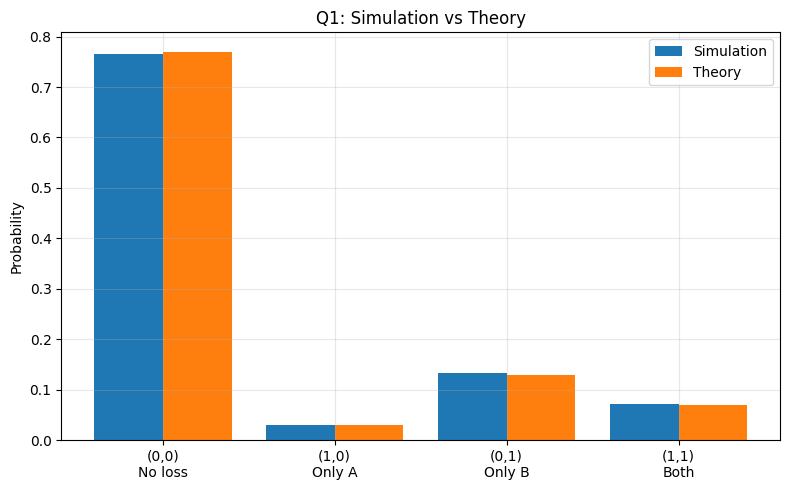


Saved: q1_plot.png


In [3]:
import numpy as np
import matplotlib.pyplot as plt

pa = 0.10
pb = 0.20
pab = 0.35
pj = pab * pb
pu = pa + pb - pj

pabc = (pa - pj) / (1 - pb)

en = pa + pb

va = pa * (1 - pa)
vb = pb * (1 - pb)

cov = pj - pa * pb

vn = va + vb + 2 * cov

pn = pa * pb
fac = pj / pn

print("THEORY")
print("P(A∩B) =", pj)
print("P(A∪B) =", pu)
print("P(A|Bc) =", pabc)
print("E[N] =", en)
print("Var(N) =", vn)
print("Factor =", fac)

# Simulation
n = 10000

rng = np.random.default_rng(42)

ib = (rng.random(n) < pb).astype(int)

pc = np.where(ib == 1, pab, pabc)

ia = (rng.random(n) < pc).astype(int)

ns = ia + ib

sj = np.mean((ia == 1) & (ib == 1))
su = np.mean((ia == 1) | (ib == 1))

sen = np.mean(ns)
svn = np.var(ns)

print("\nSIMULATION")
print("P(A∩B) =", sj)
print("P(A∪B) =", su)
print("E[N] =", sen)
print("Var(N) =", svn)

# Plot

lab = [
    "(0,0)\nNo loss",
    "(1,0)\nOnly A",
    "(0,1)\nOnly B",
    "(1,1)\nBoth"
]

cnt = [
    np.sum((ia == 0) & (ib == 0)),
    np.sum((ia == 1) & (ib == 0)),
    np.sum((ia == 0) & (ib == 1)),
    np.sum((ia == 1) & (ib == 1))
]

th = [
    1 - pu,
    pa - pj,
    pb - pj,
    pj
]

sim = [x / n for x in cnt]

x = np.arange(4)

plt.figure(figsize=(8,5))

plt.bar(
    x - 0.2,
    sim,
    0.4,
    label="Simulation"
)

plt.bar(
    x + 0.2,
    th,
    0.4,
    label="Theory"
)

plt.xticks(x, lab)

plt.ylabel("Probability")

plt.title(
    "Q1: Simulation vs Theory"
)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "q1_plot.png",
    dpi=150
)

plt.show()

print("\nSaved: q1_plot.png")

In [4]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

p = np.array([
    [0.60, 0.25, 0.05, 0.10],
    [0.00, 0.50, 0.50, 0.00],
    [0.00, 0.50, 0.50, 0.00],
    [0.00, 0.00, 0.00, 1.00]
])

st = [
    "Inv Grade",
    "Spec",
    "Dist",
    "Default"
]

pi3 = np.array([0,0,0,1])

pi12 = np.array([
    0,
    0.5,
    0.5,
    0
])

print("THEORY")

print("pi(3) =", pi3)

print("pi(1,2) =", pi12)

# Simulation

def sim(p,s,n):

    path = [s]

    for _ in range(n):

        nx = rng.choice(
            len(p),
            p=p[path[-1]]
        )

        path.append(nx)

    return path


# One path

pth = sim(
    p,
    0,
    100
)

plt.figure(
    figsize=(10,4)
)

plt.step(
    range(101),
    pth,
    where="post"
)

plt.yticks(
    [0,1,2,3],
    st
)

plt.xlabel(
    "Step"
)

plt.title(
    "Q2: Single Credit Path"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "q2_single_path.png",
    dpi=150
)

plt.close()


# 1000 simulations

n = 1000

fs = []

for _ in range(n):

    x = sim(
        p,
        0,
        100
    )

    fs.append(
        x[-1]
    )

fs = np.array(fs)

pd = np.mean(
    fs == 3
)

p12 = np.mean(
    (fs==1) |
    (fs==2)
)

p0 = np.mean(
    fs==0
)

print("\nSIMULATION")

print(
    f"Default = {pd:.3f}"
)

print(
    f"{{1,2}} = {p12:.3f}"
)

print(
    f"State 0 = {p0:.3f}"
)

cnt = [
    np.sum(fs==0),
    np.sum(fs==1),
    np.sum(fs==2),
    np.sum(fs==3)
]

plt.figure(
    figsize=(7,4)
)

plt.bar(
    st,
    [x/n for x in cnt]
)

plt.ylabel(
    "Proportion"
)

plt.title(
    "Q2: State Distribution"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "q2_plot.png",
    dpi=150
)

plt.close()

print(
    "\nSaved:"
)

print(
    "q2_single_path.png"
)

print(
    "q2_plot.png"
)

THEORY
pi(3) = [0 0 0 1]
pi(1,2) = [0.  0.5 0.5 0. ]

SIMULATION
Default = 0.234
{1,2} = 0.766
State 0 = 0.000

Saved:
q2_single_path.png
q2_plot.png


In [6]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

def sim(d,n):

    pos = np.zeros(
        d,
        dtype=int
    )

    path = [
        pos.copy()
    ]

    for _ in range(n):

        c = rng.integers(d)

        s = rng.choice(
            [-1,1]
        )

        pos[c] += s

        path.append(
            pos.copy()
        )

    return path


def ret(d,n,m):

    cnt = 0

    for _ in range(m):

        pos = np.zeros(
            d,
            dtype=int
        )

        ok = False

        for _ in range(n):

            c = rng.integers(d)

            pos[c] += rng.choice(
                [-1,1]
            )

            if np.all(pos==0):

                ok = True

                break

        cnt += ok

    return cnt/m


# Paths

fig = plt.figure(
    figsize=(14,4)
)

a1 = fig.add_subplot(131)

p1 = sim(
    1,
    1000
)

a1.plot(
    [x[0] for x in p1]
)

a1.axhline(
    0,
    ls="--"
)

a1.set_title(
    "d=1"
)

a1.grid(
    alpha=0.3
)


a2 = fig.add_subplot(132)

p2 = sim(
    2,
    1000
)

x,y = zip(
    *[(z[0],z[1]) for z in p2]
)

a2.plot(
    x,
    y
)

a2.scatter(
    0,
    0
)

a2.set_title(
    "d=2"
)

a2.grid(
    alpha=0.3
)


a3 = fig.add_subplot(
    133,
    projection="3d"
)

p3 = sim(
    3,
    1000
)

x,y,z = zip(
    *[(u[0],u[1],u[2]) for u in p3]
)

a3.plot(
    x,
    y,
    z
)

a3.scatter(
    0,0,0
)

a3.set_title(
    "d=3"
)

plt.tight_layout()

plt.savefig(
    "q3_paths.png",
    dpi=150
)

plt.close()


# Return rates

n = [
    100,
    1000,
    10000
]

d = [
    1,
    2,
    3
]

res = {}

for t in n:

    row = []

    for k in d:

        row.append(
            ret(
                k,
                t,
                1000
            )
        )

    res[t] = row

print(
    "Path      d=1    d=2    d=3"
)

for t in n:

    r = res[t]

    print(
        t,
        round(r[0],3),
        round(r[1],3),
        round(r[2],3)
    )


fig,ax = plt.subplots(
    1,
    3,
    figsize=(12,4)
)

col = [
    "steelblue",
    "orange",
    "green"
]

for i,k in enumerate(d):

    v = [
        res[t][i]
        for t in n
    ]

    ax[i].bar(
        [str(t) for t in n],
        v,
        color=col[i]
    )

    ax[i].set_title(
        f"d={k}"
    )

    ax[i].set_ylim(
        0,
        1
    )

plt.tight_layout()

plt.savefig(
    "q3_plot.png",
    dpi=150
)

plt.close()

print(
    "\nSaved:"
)

print(
    "q3_paths.png"
)

print(
    "q3_plot.png"
)

Path      d=1    d=2    d=3
100 0.912 0.588 0.299
1000 0.975 0.676 0.344
10000 0.994 0.74 0.323

Saved:
q3_paths.png
q3_plot.png


In [1]:
"""
Question 4: Market Regime Switching
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mp

rng = np.random.default_rng(42)

p = np.array([
    [0.60,0.30,0.10,0.00],
    [0.20,0.50,0.20,0.10],
    [0.10,0.30,0.40,0.20],
    [0.05,0.15,0.30,0.50]
])

st = [
    "Bull",
    "Neutral",
    "Bear",
    "Crisis"
]

r = np.array([
    0.012,
    0.004,
    -0.006,
    -0.025
])

# Stationary distribution

a = p.T - np.eye(4)

a[-1,:] = 1

b = np.zeros(4)

b[-1] = 1

pi = np.linalg.solve(
    a,
    b
)

print("="*50)

print(
    "STATIONARY DISTRIBUTION"
)

print("="*50)

for i in range(4):

    print(
        f"{st[i]} : {pi[i]:.4f}"
    )

# Long-run return

lr = pi @ r

fu = pi[2] + pi[3]

print(
    f"\nReturn = {lr:.6f}"
)

print(
    f"Bear+Crisis = {fu:.4f}"
)

# Simulation

n = 10000

s = 0

path = [s]

for _ in range(n-1):

    s = rng.choice(
        4,
        p=p[s]
    )

    path.append(s)

path = np.array(path)

ef = np.array([
    (path==i).mean()
    for i in range(4)
])

print("\nSIMULATION")

for i in range(4):

    print(
        f"{st[i]} : {ef[i]:.4f}"
    )

# Return

wr = r[path]

cr = np.cumsum(wr)

sr = wr.mean()

print(
    f"\nSim Return = {sr:.6f}"
)

# Plot 1

fig,ax = plt.subplots(
    figsize=(7,4)
)

x = np.arange(4)

w = 0.35

ax.bar(
    x-w/2,
    pi,
    w,
    label="Theory"
)

ax.bar(
    x+w/2,
    ef,
    w,
    label="Simulation"
)

ax.set_xticks(x)

ax.set_xticklabels(st)

ax.set_ylabel(
    "Fraction"
)

ax.set_title(
    "Q4: Stationary vs Empirical"
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "q4_dist.png",
    dpi=150
)

plt.close()

# Plot 2

fig,ax = plt.subplots(
    2,
    1,
    figsize=(10,8)
)

ax[0].plot(
    cr,
    color="navy"
)

ax[0].axhline(
    0,
    ls="--",
    color="black"
)

ax[0].fill_between(
    range(n),
    cr,
    0,
    where=(cr>=0),
    color="green",
    alpha=0.2
)

ax[0].fill_between(
    range(n),
    cr,
    0,
    where=(cr<0),
    color="red",
    alpha=0.2
)

ax[0].set_title(
    "Cumulative Return"
)

ax[0].grid(
    alpha=0.3
)

col = {
    0:"green",
    1:"gold",
    2:"orange",
    3:"red"
}

m = 500

for i in range(m):

    ax[1].bar(
        i,
        1,
        color=col[path[i]],
        width=1
    )

ax[1].set_xlim(
    0,
    m
)

ax[1].set_yticks([])

ax[1].set_title(
    "Regime Path"
)

leg = [
    mp.Patch(
        color=col[i],
        label=st[i]
    )
    for i in range(4)
]

ax[1].legend(
    handles=leg
)

plt.tight_layout()

plt.savefig(
    "q4_ret.png",
    dpi=150
)

plt.close()

print("\nSaved:")

print(
    "q4_dist.png"
)

print(
    "q4_ret.png"
)

STATIONARY DISTRIBUTION
Bull : 0.2524
Neutral : 0.3442
Bear : 0.2390
Crisis : 0.1644

Return = -0.001140
Bear+Crisis = 0.4034

SIMULATION
Bull : 0.2598
Neutral : 0.3386
Bear : 0.2418
Crisis : 0.1598

Sim Return = -0.000974

Saved:
q4_dist.png
q4_ret.png
